# Circuitos Eletrônicos I - T3
## Lista para a Prova

### Autor: João Victor Colombari Carlet

Neste notebook vamos analisar os circuitos propostos na lista de exercícios para a prova final.

### Ferramentas Utilizadas:
* **`ngspice`**: Nosso motor de simulação de backend, encarregado de resolver as equações matriciais não-lineares dos diodos.
* **`PySpice`**: A biblioteca de ponte que traduz comandos do Python para comandos interpretados pelo SPICE.


## Passo 0: Inicializando o Ambiente de Simulação e Gráficos


Vamos verificar se as ferramentas do `matplotlib` para gerar curvas de alta resolução, o leitor de arquivos (`SpiceParser`) do `PySpice`, e o numpy estão instalados e depois importar tudo.

> **Importante:** Para executar as simulações localmente, vocês vão precisar do ngspice instalado. Pelo OSX é só executar: 

```bash
brew install ngspice
```

No Linux:

```bash
sudo apt-get update
sudo apt-get install ngspice
```

No windows fico devendo, mas não deve ser dificil.. 

In [1]:
import sys
print(f"Ambiente ativo: {sys.executable}")

# Instalação silenciosa das dependências necessárias no kernel atual
!{sys.executable} -m pip -q install numpy matplotlib pyspice schemdraw

Ambiente ativo: /Users/joaovitor/Documents/PhD/PAE/eletronicos_I/prova/venv/bin/python

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
from PySpice.Spice.Parser import SpiceParser
from PySpice.Unit import *
import numpy as np

print("Bibliotecas prontas para simulação.")

Bibliotecas prontas para simulação.


---
# Exercício 1: Diagrama de bandas e alguns problemas teóricos do bipolar

1 - Desenhe os níveis de energia (EC, EV, Ei e EF) e densidade de portadores para um transistor NPN polarizado diretamente (Vbe > 0,6 V; Vbc < 0V).

2 - Desenhe os níveis de energia (EC, EV, Ei e EF) e densidade de portadores para um transistor PNP polarizado diretamente (Vbe < - 0,6 V; Vbc > 0V).

3 - O que causa o efeito Early (fisicamente)?

4 - Por que em um transistor bipolar é bom que a concentração de impurezas na base seja maior do que a concentração no coletor?

5 - Considere agora dois diodos NP ligados de forma semelhante a um transistor bipolar (Figura 1). Refazer os itens 1.1 e 1.2.  

---

#### Para desenhar os diagramas é que nem na lista 2. Desenha separadamente cada porção de silicio alinhando os níveis de fermi (mais ou menos o deslocamento $q|V|$ da polarização) e depois conecta $E_V$, $E_i$ e $E_C$.

No caso do transistor, a largura da base $W_B$ é pequena e a dopagem da base é menor que a do emissor, isso faz com que haja pouca recombinação e que a corrente de elétrons seja maior que a de lacunas na base, o que muda o diagrama de densidade de portadores entre transistor e diodos conectados. 

O diagrama de bandas do NPN é o seguinte:

<p align="center">
    <img src="figuras/f1.png" width="800">
</p>

E o diagrama de densidade de portadores:

<p align="center">
    <img src="figuras/f2.png" width="800">
</p>

Enquanto que nos diodos fica da seguinte forma:

<p align="center">
    <img src="figuras/f3.png" width="800">
</p>

Para a prova, se pedido como no item 1.5 mostrem a distinção do $W_B$ e o comportamento a concentração de portadores na base. 

Para o PNP o comportamento é análogo, mudando a direção das coisas. Preservem a ordem dos terminais para facilitar a comparação entre os dois. 

#### O Efeito Early 

Esse é o efeito que faz com que o transistor não seja uma fonte de corrente controlada por tensão ideal, mostrando uma inclinação na família de curvas. 

Ele é causado pela diminuição da largura efetiva da base do transistor $W_{Bef}$. Quando a tensão reversa aumenta, a região de depleção aumenta e isso acarreta no aumento de $W_{Bef}$, o que aumenta a corrente. 

#### As impurezas no coletor 

Vai meio na linha do que acontece com o Early. Se $W_{Bef}$ diminui, é bom controlar esse fenomeno. Se a dopagem no coletor fosse muito alta, a região de depleção entre base e coletor iria entrar na emissor base, o que não é legal. 

Rule of thumb é então 

$$
    N_{DE} >> N_A > N_{DC}
$$

---
# Exercício 2: Sedra

Neste recorram ao solucionário do Sedra. Em caso de dúvida me enviem um email.
---

---
# Exercício 3: Push-Pull/Inversos

Neste exercício, vamos analizar um circuito Push-Pull/Inversos, que é extremamente usado. 
---

#### Análise rápida do circuito

Nesse ou um ou outro conduz, sendo que de $-0.7$ a $0.7V$ ambos estão em corte. Quando a entrada é menor que $-0.7V$, $V_{BE}$ do transistor de baixo é meior que o limiar, então o transistor PNP puxa (pull) corrente, enquanto que o NPN fica cortado. Para o oposto, o NPN empurra (push) corrente, o que da o comportamento do circuito. 

A tensão de saída segue a entrada de maneira linear a menos de $|0.7|V$ até que sature.

Nesse exercicio tem um pulo do gato que é o resistor das bases, então precisamos considerar essa queda na entrada. 

Com $V_{BE}=0,7,V$:

$$
V_O = V_B - 0,7
$$

A corrente na carga é

$$
I_L=\frac{V_O}{R_L}
$$

Como a corrente de emissor é a corrente da carga (pq os transistores operam intermitentemente),

$$
I_E=I_L
$$

e

$$
I_E=(\beta+1)I_B
$$

Se tem que:

$$
\frac{V_O}{R_L(\beta+1)}
$$

Por outro lado, a corrente na resistência de base é

$$
I_B=\frac{V_{in}-V_B}{R_B}
$$

Substituindo $V_B=V_O+0,7$:

$$
\frac{V_O}{R_L(\beta+1)}
$$

Com

$$
V_{in}=5V,\quad
R_B=10k\Omega,\quad
R_L=1k\Omega,\quad
\beta=100
$$

resulta

$$
\frac{V_O}{101000}
$$

Resolvendo:

$$
101(4,3-V_O)=10V_O
$$

$$
434,3=111V_O
$$

$$
V_O=3,91V
$$

Logo,

$$
I_L=\frac{3,91}{1000}
=3,91,mA
$$


Node name 'in' is a Python keyword
Unsupported Ngspice version 46


Simulação do Circuito concluída com sucesso.


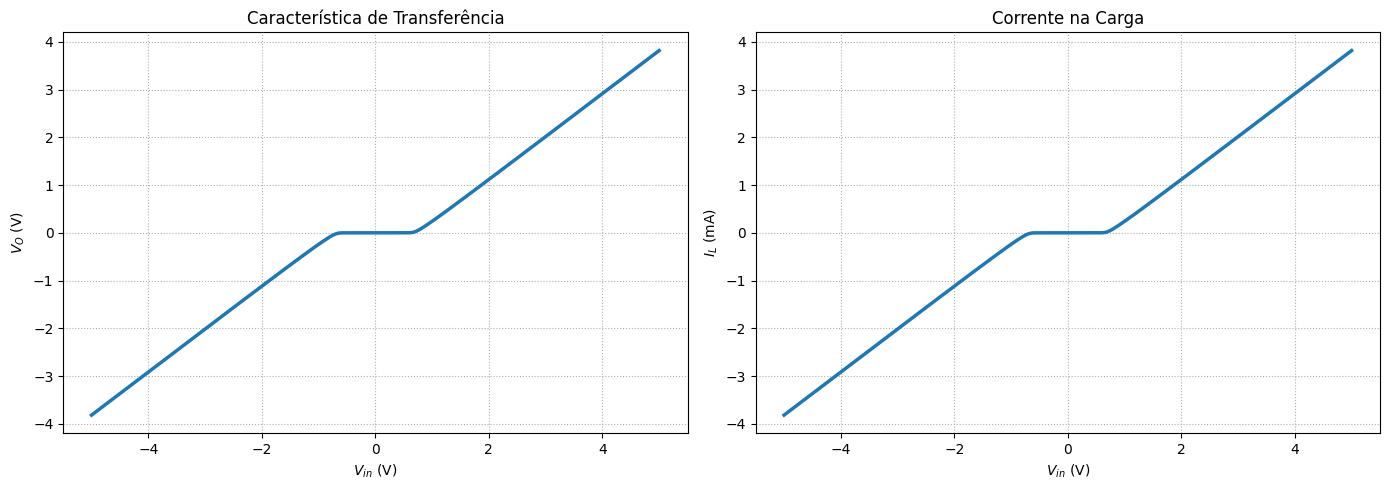

In [3]:
# 1. Carrega o arquivo de netlist exportado do LTspice
analysis = SpiceParser(path='netlists/q3/circuit.net').build_circuit().simulator().dc(V1=slice(-5, 5, 0.05))

print("Simulação do Circuito concluída com sucesso.")

# Tensões
vin = np.array(analysis.sweep)
vo = np.array(analysis['n002'])

# Corrente na carga
RL = 1000
il = vo / RL * 1000  # mA

# Plotagem
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(vin, vo, linewidth=2.5)
axs[0].set_title('Característica de Transferência')
axs[0].set_xlabel('$V_{in}$ (V)')
axs[0].set_ylabel('$V_O$ (V)')
axs[0].grid(True, linestyle=':')

axs[1].plot(vin, il, linewidth=2.5)
axs[1].set_title('Corrente na Carga')
axs[1].set_xlabel('$V_{in}$ (V)')
axs[1].set_ylabel('$I_L$ (mA)')
axs[1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

---
# Exercício 3: Push-Pull/Inversos

Neste exercício, vamos analizar um circuito emissor comum com bypass (não degenerado). Esse é um circuito que tudo tem que estar na ponta da lingua. 

Uma vez fiz uma entrevista de emprego e o cara literalmente me perguntou o ganho disso.. 
---

#### Análise rápida do circuito

Aqui vamos dar uma olhada no circuito a pequenos sinais. Peguei uma análise nos slides, então desconsidere os valores:

<p align="center">
    <img src="figuras/f4.png" width="800">
</p>

Fica claro que o ganho vai ser a resistencia na saída vezesa transcondutancia, o que é verdade quase sempre, seja para válvula, bipolar, JFET ou MOS. 

Aqui vou considerar $r_0$, mas faz as contas aí para ver que a diferença é pequena (porque?):

#### 1. Determinação de $R_C$ e $I_C$ para Ganho $A_v = -40$ e $V_C = 4,0\text{ V}$

O ganho de tensão a pequenos sinais é:
$$A_v = -g_m \cdot (r_0 \parallel R_C \parallel R_L)$$

Substituindo $g_m = \frac{I_C}{V_T}$ e abrindo o paralelo de saída, temos:
$$A_v = -\frac{I_C}{V_T} \cdot \left( \frac{1}{\frac{1}{r_0} + \frac{1}{R_C} + \frac{1}{R_L}} \right)$$

Como $r_0 = \frac{V_{AF}}{I_C}$, podemos substituir $\frac{1}{r_0}$ por $\frac{I_C}{V_{AF}}$:
$$A_v = -\frac{I_C}{V_T} \cdot \left( \frac{1}{\frac{I_C}{V_{AF}} + \frac{1}{R_C} + \frac{1}{R_L}} \right)$$

Pela malha de saída em corrente contínua (CC), mantemos a relação:
$$V_C = V_{DD} - R_C \cdot I_C \implies 4,0 = 6,0 - R_C \cdot I_C \implies R_C = \frac{2,0}{I_C}$$

Substituindo $\frac{1}{R_C} = \frac{I_C}{2,0}$ e os valores conhecidos ($A_v = -40$, $V_T = 0,02586\text{ V}$, $V_{AF} = 100\text{ V}$ e $R_L = 1000\text{ }\Omega$) na equação do ganho:
$$40 = \frac{I_C}{0,02586} \cdot \left( \frac{1}{\frac{I_C}{100} + \frac{I_C}{2,0} + \frac{1}{1000}} \right)$$

Colocando $I_C$ em evidência no denominador para simplificar com o numerador:
$$40 = \frac{I_C}{0,02586} \cdot \left( \frac{1}{I_C \cdot \left( \frac{1}{100} + \frac{1}{2,0} \right) + 0,001} \right)$$

$$\implies I_C = \frac{0,04}{18,27} \approx 0,00219\text{ A} = \mathbf{2,19\text{ mA}}$$

Agora, isolando e determinando o valor exato necessário para $R_C$:
$$R_C = \frac{2,0\text{ V}}{2,19\text{ mA}} \approx \mathbf{913\text{ }\Omega}$$

### 2. Faixa de Valores para Polarização de $V_b$ e Melhor Valor

A saída $V_o$ está acoplada no nó do coletor ($V_C$). Para uma excursão simétrica de $\pm 1,0\text{ V}$, a tensão $V_C$ oscila entre $3,0\text{ V}$ e $5,0\text{ V}$.

**1 - Não saturar:** No pior caso ($V_{C,min} = 3,0\text{ V}$), precisa garantir que $V_{CE} > V_{CE,sat} \approx 0,2\text{ V}$.
    $$V_{C,min} - V_E > 0,2 \implies 3,0 - (V_b - 0,7) > 0,2 \implies V_b < 3,5\text{ V}$$

**2 - Não cortar:** a junção base-emissor deve permanecer diretamente polarizada ($V_b > 0,7\text{ V}$).

**Faixa permitida:** $0,7\text{ V} < V_b < 3,5\text{ V}$.

**Melhor Valor:** **$V_b = 2,0\text{ V}$**. 
Com a tensão de emissor em $V_E = 1,3\text{ V}$, a tensão $V_{CE}$ fica estável em $2,7\text{ V}$ no ponto de operação, mantendo o transistor na Região Ativa com margem contra a saturação ($V_{CE,min} = 3,0 - 1,3 = 1,7\text{ V} \gg 0,2\text{ V}$).

#### 3. Determinação exata de $R_E$, $R_{b1}$ e $R_{b2}$ considerando o efeito de carga na base

Para garantir que o circuito atinja a corrente projetada de $I_C = 2,19\text{ mA}$ (necessária para cravar o ganho em $-40$ com o $V_T$ e $r_0$ do SPICE), precisamos descontar as quedas de tensão reais na malha de entrada.

* **Cálculo de $R_E$:**
  Considerando a corrente de emissor exata $I_E = I_C \cdot \frac{\beta + 1}{\beta} = 2,19\text{ mA} \cdot 1,01 = 2,2119\text{ mA}$ e a tensão desejada de $V_E = 1,3\text{ V}$:
  $$R_E = \frac{V_E}{I_E} = \frac{1,3\text{ V}}{2,2119\text{ mA}} \approx \mathbf{593,61\text{ }\Omega}$$

* **Cálculo dos Resistores de Base ($R_{b1}$ e $R_{b2}$):**
  Aqui é massa evitar valores altos de resistores para reduzir indutâncias parasitas dos componentes reais e ruído branco. Aqui vou usar +- 10 vezes a resistencia do emissor: $R_{Th} \approx 5,9\text{ k}\Omega$. 
  
  Como a base do transistor drena uma corrente $I_B = \frac{I_C}{\beta} = 21,9\text{ }\mu\text{A}$, a tensão de Thévenin do divisor ($V_{Th}$) deve ser dimensionada para compensar a queda de tensão sobre $R_{Th}$:
  $$V_{Th} = R_{Th} \cdot I_B + V_B$$
  
  Onde $V_B = V_E + V_{BE} = 1,3\text{ V} + 0,7\text{ V} = 2,0\text{ V}$. Portanto:
  $$V_{Th} = (5900\text{ }\Omega \cdot 21,9\text{ }\mu\text{A}) + 2,0\text{ V} = 0,129\text{ V} + 2,0\text{ V} = \mathbf{2,129\text{ V}}$$

  Agora, aplicamos as relações do equivalente de Thévenin para isolar os componentes a partir de $V_{DD} = 6,0\text{ V}$:
  
  1. Para $R_{b1}$ (resistor conectado ao $V_{CC}$):
     $$R_{b1} = V_{DD} \cdot \frac{R_{Th}}{V_{Th}} = 6,0 \cdot \frac{5900}{2,129} \approx \mathbf{16,63\text{ k}\Omega}$$

  2. Para $R_{b2}$ (resistor conectado ao terra):
     Usando a relação do divisor de tensão $V_{Th} = V_{DD} \cdot \frac{R_{b2}}{R_{b1} + R_{b2}}$:
     $$2,129 = 6,0 \cdot \frac{R_{b2}}{16630 + R_{b2}} \implies \mathbf{R_{b2} \approx 9,14\text{ k}\Omega}$$

#### 4. Impedâncias de Entrada ($Z_{in}$) e Saída ($Z_{out}$)

* **Impedância de Entrada ($Z_{in}$):**
    Com o emissor aterrado pelo capacitor $C_E$ para sinais CA, a impedância vista pela base é $r_\pi$:
    $$r_\pi = \frac{\beta \cdot V_T}{I_C} = \frac{100 \cdot 25\text{ mV}}{2\text{ mA}} = 1250\text{ }\Omega = 1,25\text{ k}\Omega$$
    $$Z_{in} = R_{b1} \parallel R_{b2} \parallel r_\pi = 8,85\text{ k} \parallel 17,7\text{ k} \parallel 1,25\text{ k} \approx \mathbf{1,03\text{ k}\Omega}$$

Se tiver sem tempo para calcular fala que vai ficar proxima de $r_\pi$

* **Impedância de Saída ($Z_{out}$):**
    Desconsiderando a carga externa $R_L$:
    $$Z_{out} = R_C||r_0 = 1,0\text{ k}\Omega||50,0\text{ k}\Omega \approx 895,10 \Omega$$

#### 5. Condição para o Capacitor de Entrada $C_b$ ($f > 1,0\text{ kHz}$)

O capacitor $C_b$ forma um filtro passa-altas com a impedância de entrada do circuito ($Z_{in}$). Para que os sinais passem sem atenuação na frequência de corte limite:
$$f_c = \frac{1}{2\pi \cdot Z_{in} \cdot C_b} \leq 1000\text{ Hz}$$
$$C_b \geq \frac{1}{2\pi \cdot 1050 \cdot 1000} \approx 1,51 \cdot 10^{-7}\text{ F} \implies \mathbf{C_b \geq 151\text{ nF}}$$

#### 6. Análise com o Capacitor $C_E$ Queimado (Aberto)

Caso $C_E$ esteja aberto, ampli passa a ter degeneração no emissor (ocorre uma realimentação negativa). Desconsiderando o $r_0$, a nova equação do ganho (olhar nos slides a partir do 715 e resolver para uma fonte ideal) passa a ser:

$$A_v = -gm \cdot (R_C \parallel R_L) \frac{r_\pi}{r_\pi + (\beta + 1)R_E}$$

Calculando o paralelo da carga com o coletor ($R_C \parallel R_L = 1\text{ k} \parallel 1\text{ k} = 500\text{ }\Omega$):

$$A_v = -96,29m \cdot (1k \parallel 913) \frac{1,25k}{1,25k + (200 + 1)593,61} \approx -0,94V/V$$

**Conclusão:** O ganho cai drasticamente devido à forte realimentação negativa introduzida por $R_E$.    

Node name 'in' is a Python keyword


Simulação concluída com sucesso.
Ganho = 40.23 V/V


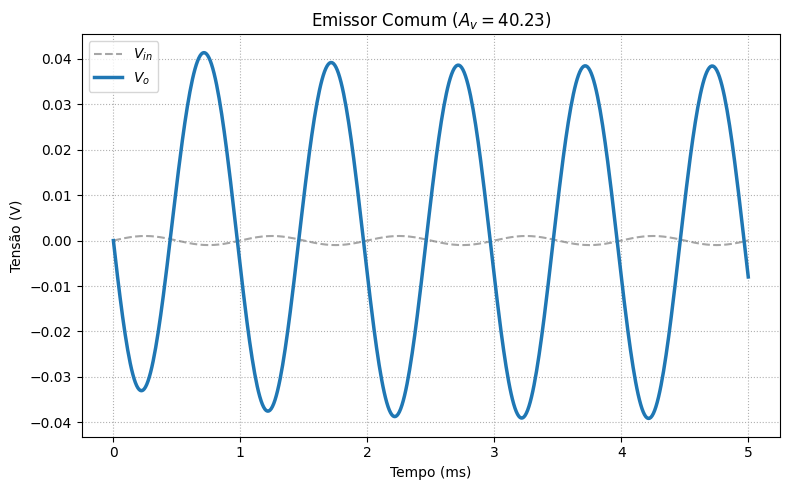

In [5]:
# Carrega o circuito
analysis = (SpiceParser(path='netlists/q4/circuit.net').build_circuit().simulator().transient(step_time=10e-6, end_time=5e-3))
print("Simulação concluída com sucesso.")

# Tempo
t = np.array(analysis.time) * 1000

# Tensões
vin = np.array(analysis['in'])
vout = np.array(analysis['out'])

# Ganho (pico a pico)
Av = (vout.max() - vout.min()) / (vin.max() - vin.min())

print(f"Ganho = {Av:.2f} V/V")

# Plota
plt.figure(figsize=(8,5))

plt.plot(t, vin, '--', color='gray', alpha=0.7, label='$V_{in}$')
plt.plot(t, vout, linewidth=2.5, label='$V_{o}$')

plt.title(f'Emissor Comum ($A_v={Av:.2f}$)')
plt.xlabel('Tempo (ms)')
plt.ylabel('Tensão (V)')
plt.grid(True, linestyle=':')
plt.legend()

plt.tight_layout()
plt.show()

---
# Exercício 5: Emissor simplificado

Este exercício é muito parecido com o outro mas é bem simplificado, o que quer dizer que as simulações vão ficar fora. Vou aproveitar para mostrar como calcula impedancia de saída e entrada no spice.
---

#### Dados Iniciais do Circuito 
* $V_{DD} = 6,0\text{ V}$
* $R_{b1} = 4,0\text{ k}\Omega$ (conectado ao terra)
* $R_{b2} = 2,0\text{ k}\Omega$ (conectado ao $V_{DD}$)
* $R_E = 1,6\text{ k}\Omega$
* Parâmetros do Transistor: $V_{BE} = 0,6\text{ V}$, $V_{CE,sat} = 0,4\text{ V}$

#### 1. Calcular os valores da tensão $V_b$ e da corrente $I_c$ ($\beta$ bem alto)

Como o enunciado especifica que o valor de $\beta$ é bem alto ($\beta \rightarrow \infty$), a corrente de base é desprezível ($I_B \approx 0$). Dessa forma, o divisor de tensão na base comporta-se de maneira ideal.

* **Cálculo de $V_b$:**
  $$V_b = V_{DD} \cdot \frac{R_{b1}}{R_{b1} + R_{b2}} = 6,0\text{ V} \cdot \frac{4\text{ k}}{4\text{ k} + 2\text{ k}} = 6,0 \cdot \frac{4}{6} = \mathbf{4,0\text{ V}}$$

* **Cálculo de $I_c$:**
  Primeiro, encontramos a tensão no emissor ($V_E$):
  $$V_E = V_b - V_{BE} = 4,0\text{ V} - 0,6\text{ V} = 3,4\text{ V}$$
  
  A corrente de emissor ($I_E$) será:
  $$I_E = \frac{V_E}{R_E} = \frac{3,4\text{ V}}{1,6\text{ k}\Omega} = 2,125\text{ mA}$$
  
  Como $\beta$ é muito alto, $I_c \approx I_E$:
  $$I_c = \mathbf{2,125\text{ mA}}$$

#### 2. Determinar o valor de $R_c$ para obter o maior ganho de tensão ($V_{in} \leq \pm 5,0\text{ mV}$)

O ganho de tensão em malha aberta para o emissor comum com bypass é dado por $A_v = -g_m \cdot R_c$. Para maximizar o ganho, precisamos maximizar o valor de $R_c$. 

No entanto, $R_c$ é limitado superiormente para evitar que o pico inferior da oscilação do sinal de saída force o transistor a entrar na região de saturação ($V_{CE} \leq V_{CE,sat}$).

Com um sinal de entrada de pico $V_{in,pk} = 5,0\text{ mV}$, o pico da oscilação de saída será $\Delta V_o = |A_v| \cdot V_{in,pk}$. 
Para obter a máxima excursão simétrica sem distorcer por saturação, o ponto de operação CC do coletor ($V_C$) deve ser projetado exatamente no ponto médio entre o limite superior ($V_{DD} = 6,0\text{ V}$) e o limite inferior de saturação ($V_{E} + V_{CE,sat} = 3,4 + 0,4 = 3,8\text{ V}$).

$$V_{C} = \frac{V_{DD} + (V_E + V_{CE,sat})}{2} = \frac{6,0 + 3,8}{2} = \mathbf{4,9\text{ V}}$$

Agora, aplicando a malha de saída CC para encontrar o $R_c$ máximo permitido:
$$V_C = V_{DD} - R_c \cdot I_c \implies 4,9 = 6,0 - R_c \cdot (2,125\text{ mA})$$
$$R_c \cdot (2,125\text{ mA}) = 1,1\text{ V} \implies R_c = \frac{1,1}{2,125\text{ mA}} \approx \mathbf{517,65\text{ }\Omega}$$

#### 3. Calcule a impedância AC da entrada (use $\beta = 160$)

Com o capacitor $C_E$ atuando como um curto-circuito ideal em CA, o emissor está aterrado para os pequenos sinais. A impedância vista olhando para a base do transistor é $r_\pi$.

* **Cálculo de $r_\pi$:**
  $$g_m = \frac{I_c}{V_T} = \frac{2,125\text{ mA}}{25\text{ mV}} = 0,085\text{ A/V} = 85\text{ mA/V}$$
  $$r_\pi = \frac{\beta}{g_m} = \frac{160}{0,085} \approx \mathbf{1882,35\text{ }\Omega}\text{ (ou } 1,88\text{ k}\Omega)$$

* **Impedância de Entrada Total ($Z_{in}$):**
  Em pequenos sinais, as fontes CC são aterradas, deixando os resistores do divisor de base em paralelo com a entrada:
  $$Z_{in} = R_{b1} \parallel R_{b2} \parallel r_\pi = 4\text{ k} \parallel 2\text{ k} \parallel 1,882\text{ k}$$
  
  Calculando o paralelo:
  $$R_{b1} \parallel R_{b2} = \frac{4 \cdot 2}{4 + 2} = 1,333\text{ k}\Omega$$
  $$Z_{in} = 1,333\text{ k} \parallel 1,882\text{ k} = \frac{1,333 \cdot 1,882}{1,333 + 1,882} \approx \mathbf{781\text{ }\Omega}$$

#### 4. Desenhe os sinais em $V_b$, $V_e$ e $V_o$ no tempo ($V_{in} = 5,0 \cdot \sin(\omega t)\text{ mV}$)

Para esboçar os gráficos no tempo, combinamos os níveis contínuos (CC) com as oscilações de pequenos sinais (CA).

* **Ganho do circuito com o $R_c$ projetado:**
  $$A_v = -g_m \cdot R_c = -85\text{ mA/V} \cdot 517,65\text{ }\Omega \approx -44$$
  A amplitude do sinal de saída será: $V_{o,pk} = 44 \cdot 5\text{ mV} = 220\text{ mV} = 0,22\text{ V}$.

#### Comportamento dos nós no tempo:

* **Nó $V_b$ (Base):** Apresenta o nível CC de $4,0\text{ V}$ somado ao sinal senoidal de entrada de $5\text{ mV}$ em fase.
  $$V_b(t) = 4,0\text{ V} + 5,0 \cdot \sin(\omega t)\text{ mV}$$
* **Nó $V_e$ (Emissor):** Devido ao capacitor de bypass $C_E$, o sinal CA é desviado para o terra. A tensão no emissor permanece perfeitamente estável no seu nível CC. (IDEAL HEIM, NA REAL TEM UMA MODULACAO PROPORCIONAL A IMPEDANCIA NO EMISSOR)
  $$V_e(t) = 3,4\text{ V}$$
* **Nó $V_o$ (Coletor / Saída):** Apresenta o nível CC de $4,9\text{ V}$ somado ao sinal amplificado e **invertido** ($180^\circ$ defasado) com amplitude de $0,22\text{ V}$.
  $$V_o(t) = 4,9\text{ V} - 0,22 \cdot \sin(\omega t)\text{ V}$$

Node name 'in' is a Python keyword


Simulação concluída com sucesso.
Ganho = 40.46 V/V


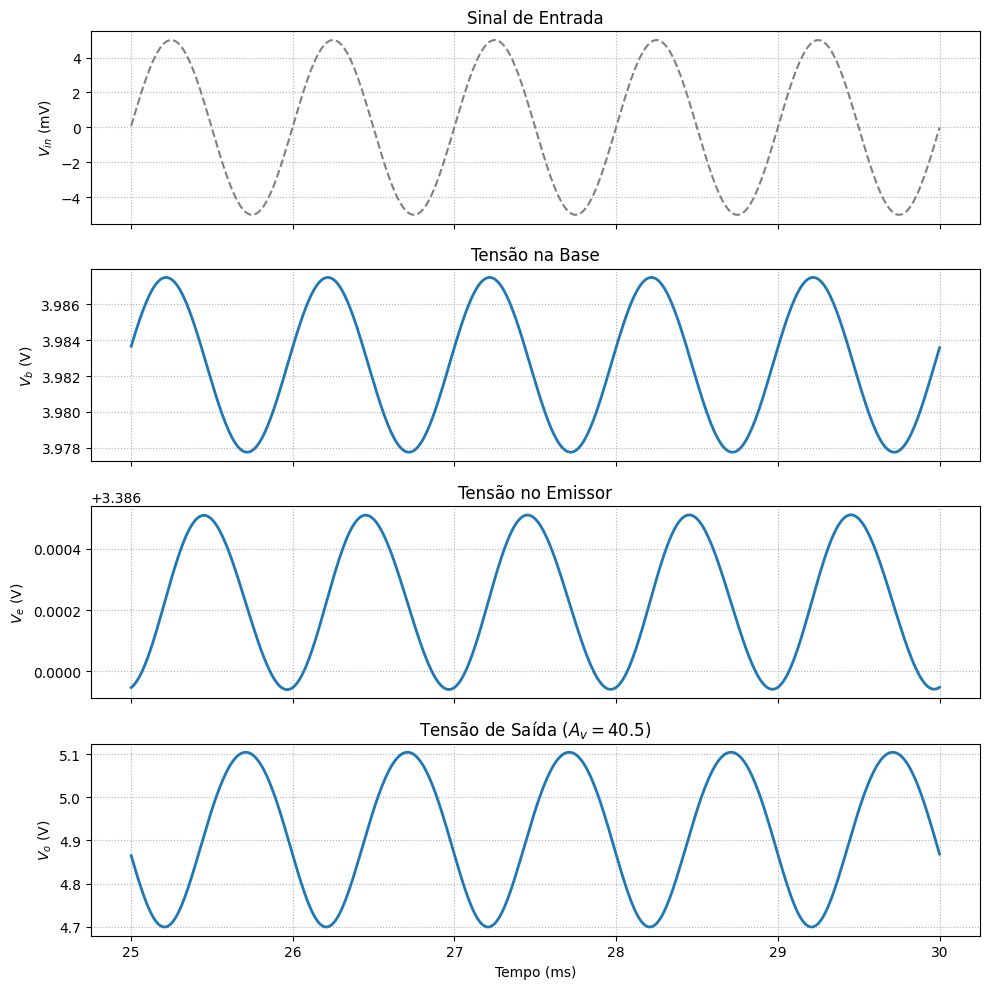

In [ ]:
# Simulação transiente pras formas de onda. 
analysis = (SpiceParser(path='netlists/q5/circuit.net').build_circuit().simulator().transient(step_time=10e-6,end_time=30e-3,use_initial_condition=False,start_time=25e-3))

print("Simulação concluída com sucesso.")

# Tempo (ms)
t = np.array(analysis.time) * 1000

# Tensões
vin  = np.array(analysis['in'])
vb   = np.array(analysis['n001'])
ve   = np.array(analysis['n002'])
vo   = np.array(analysis['out'])

# Ganho (pico a pico)
Av = (vo.max() - vo.min()) / (vin.max() - vin.min())

print(f"Ganho = {Av:.2f} V/V")

# Plota
fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

axs[0].plot(t, vin*1000, '--', color='gray', linewidth=1.5)
axs[0].set_ylabel('$V_{in}$ (mV)')
axs[0].set_title('Sinal de Entrada')
axs[0].grid(True, linestyle=':')

axs[1].plot(t, vb, linewidth=2)
axs[1].set_ylabel('$V_b$ (V)')
axs[1].set_title('Tensão na Base')
axs[1].grid(True, linestyle=':')

axs[2].plot(t, ve, linewidth=2)
axs[2].set_ylabel('$V_e$ (V)')
axs[2].set_title('Tensão no Emissor')
axs[2].grid(True, linestyle=':')

axs[3].plot(t, vo, linewidth=2)
axs[3].set_ylabel('$V_o$ (V)')
axs[3].set_xlabel('Tempo (ms)')
axs[3].set_title(f'Tensão de Saída ($A_v={Av:.1f}$)')
axs[3].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

Esse circuito está como na lista:

<p align="center">
    <img src="figuras/f5.png" width="800">
</p>

Se eu quiser determinar as impedancias direto nele, existem duas maneiras, uma mais chique e uma mais visual. 

A visual é basicamente o que se faz na mão. Quando quero a impedancia de entrada, uso uma tensão ou corrente de teste, determinando a impedancia como a razão entre a tensão e a corrente de teste, ou seja $Z_{in}=v_x/i_x$. No caso da saída, analogamente, desativo a entrada e aplico uma tensão ou corrente de teste e calculo como antes. Isso pode ser feito de maneira direta no spice com uma simulação `.AC`.

Para visualizar a impedancia, no LTSpice vá em add traces, selecione a tensão de teste, edite o valor dela clicando la encima com o botão direito e divida pela corrente de teste. Tendo a forma de onda, clique com o botão direito no eixo vertical e selecione a visualização linear (aqui eu exagerei nos capacitores para não influenciar):

<p align="center">
    <img src="figuras/f6.png" width="800">
</p>

Para a saída é a mesma coisa. Neste circuito vai ser uma fonte de corrente para não aterrar o nó de saída. Se fosse acoplado com um capacitor daria para usar uma fonte de tensão tbm:

<p align="center">
    <img src="figuras/f7.png" width="800">
</p>

A outra forma, mais chique, é tratar o circuito como uma rede através do `.net`. Para isso basta entrar a referencia de saída e a fonte de entrada do circuito, como `.net v(out) V1`, se V1 for a fonte de entrada. Isso infelizmente só funciona no LTSpice.. 

Vão aqui as netlists pro NG:

Node name 'in' is a Python keyword


Simulações concluídas com sucesso.


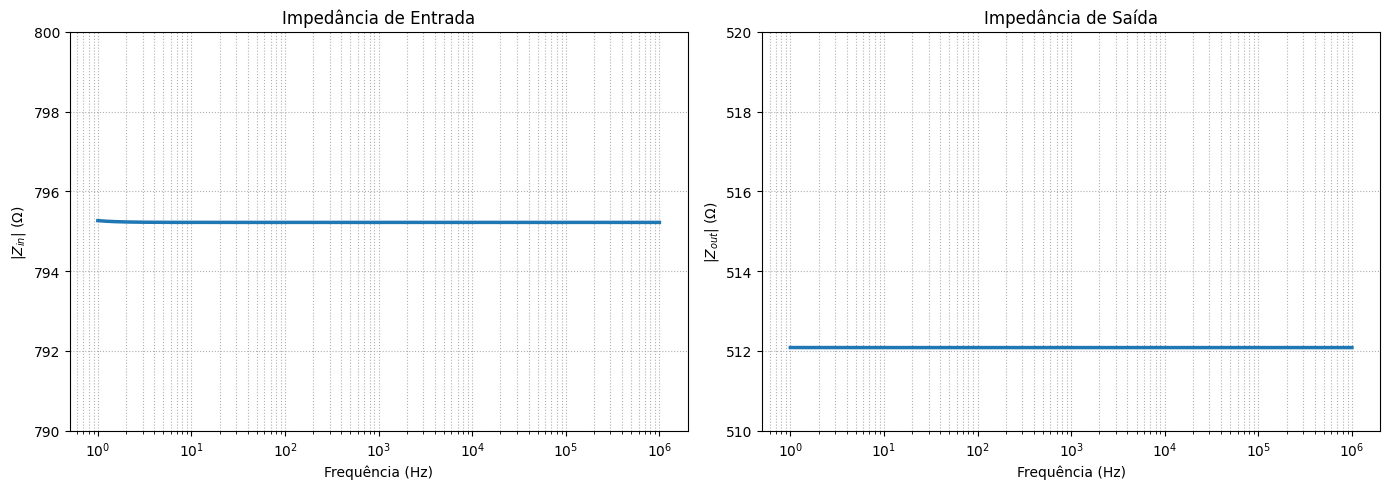

In [25]:
# --- Impedância de Entrada ---
analysis_in = (SpiceParser(path='netlists/q5/circuit_input_impedance.net').build_circuit().simulator().ac(number_of_points=1000,variation='dec',start_frequency=1,stop_frequency=1e6))

# --- Impedância de Saída ---
analysis_out = (SpiceParser(path='netlists/q5/circuit_output_impedance.net').build_circuit().simulator().ac(number_of_points=1000,variation='dec',start_frequency=1,stop_frequency=1e6))

print("Simulações concluídas com sucesso.")

# Frequência
f_in = np.array(analysis_in.frequency)
f_out = np.array(analysis_out.frequency)

# Zin = Vin / I(V1)
iin = np.array(analysis_in.branches['v1'])
zin = np.abs(1 / iin)

# Zout = V(out) / I1  (I1 = 1 A)
vout = np.array(analysis_out['out'])
zout = np.abs(vout)

# Plotagem
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].semilogx(f_in, zin, linewidth=2.5)
axs[0].set_title('Impedância de Entrada')
axs[0].set_xlabel('Frequência (Hz)')
axs[0].set_ylabel(r'$|Z_{in}|$ ($\Omega$)')
axs[0].grid(True, which='both', linestyle=':')
axs[0].set_ylim(790, 800)
axs[1].semilogx(f_out, zout, linewidth=2.5)
axs[1].set_title('Impedância de Saída')
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel(r'$|Z_{out}|$ ($\Omega$)')
axs[1].grid(True, which='both', linestyle=':')
axs[1].set_ylim(510, 520)

plt.tight_layout()
plt.show()

---
# Exercício 6: Amplificador Base Comum com espelho de corrente 
---

### Dados Iniciais do Circuito (Figura 5)
* $V_{DD} = 5,0\text{ V}$
* $R_{b1} = 2,0\text{ k}\Omega$, $R_{b2} = 3,0\text{ k}\Omega$
* $R_C = 2,0\text{ k}\Omega$, $R_s = 50\text{ }\Omega$
* $R_1 = 4,7\text{ k}\Omega$
* Transistores: $\beta = 100$, $V_{BE} = 0,7\text{ V}$
* Geometria do Espelho: Área de $Q_2 = 0,5 \cdot$ Área de $Q_3 \implies I_{S2} = 0,5 \cdot I_{S3}$
* Parâmetro de Efeito Early adotado: $V_{AF} = 100\text{ V}$
* Tensão térmica: $V_T \approx 25\text{ mV}$

---

#### 1. Cálculo do Ponto de Operação 

**Determinação da Corrente de Referência ($I_{REF}$)**

A malha de referência do espelho de corrente no lado direito ($Q_3$ conectado como diodo) fornece:
$$V_{DD} = R_1 \cdot I_{REF} + V_{BE3}$$
$$5,0\text{ V} = 4,7\text{ k}\Omega \cdot I_{REF} + 0,7\text{ V} \implies I_{REF} = \frac{4,3}{4,7\text{ k}\Omega} \approx 0,9149\text{ mA}$$

**Corrente do Espelho ($I_{C2}$) e Corrente de Emissor de $Q_1$**

Como $Q_2$ possui metade da área de condução de $Q_3$, a corrente de coletor espelhada será:
$$I_{C2} = 0,5 \cdot I_{REF} = 0,5 \cdot 0,9149\text{ mA} = 0,4575\text{ mA}$$

Essa corrente é injetada diretamente no nó do emissor de $Q_1$. Portanto, fixamos a corrente CC de emissor do amplificador:
$$I_{E1} = I_{C2} = 0,4575\text{ mA}$$

Consequentemente, a corrente de base de $Q_1$ que interage com o divisor é:
$$I_{B1} = \frac{I_{E1}}{\beta + 1} = \frac{0,4575\text{ mA}}{101} \approx 4,53\text{ }\mu\text{A}$$

**Cálculo de $V_b$ por Análise de Nós (KCL na Base)**

Aplicando a Lei das Correntes de Kirchhoff diretamente no nó da base ($V_b$), onde a corrente que entra pelo resistor superior ($R_{b2}$) deve ser igual à soma das correntes que saem pelo resistor inferior ($R_{b1}$) e pela base do transistor ($I_{B1}$):

$$\frac{5 - V_b}{3\text{ k}} = \frac{V_b}{2\text{ k}} + I_{B1}$$

Substituindo $I_{B1} = 4,53\text{ }\mu\text{A}$ e multiplicando toda a equação por $6\text{ k}$ para eliminar os denominadores:
$$2 \cdot (5 - V_b) = 3 \cdot V_b + (6\text{ k} \cdot 4,53\text{ }\mu\text{A})$$
$$10 - 2V_b = 3V_b + 0,02718\text{ V}$$
$$10 - 0,02718 = 5V_b \implies 9,97282 = 5V_b$$
$$V_b = \frac{9,97282}{5} \approx \mathbf{1,9946\text{ V}}$$

**Tensões de Nó Restantes ($V_E$ e $V_C$)**

* **Tensão no Emissor ($V_E$):**
  $$V_E = V_b - V_{BE1} = 1,9946\text{ V} - 0,7\text{ V} = \mathbf{1,2946\text{ V}}$$

* **Tensão no Coletor ($V_C$):**
  Com $\alpha = \frac{100}{101} \approx 0,9901$, a corrente de coletor de $Q_1$ é $I_{C1} = \alpha \cdot I_{E1} \approx 0,453\text{ mA}$:
  $$V_C = V_{DD} - R_C \cdot I_{C1} = 5,0\text{ V} - (2\text{ k}\Omega \cdot 0,453\text{ mA}) = 5,0 - 0,906 = \mathbf{4,094\text{ V}}$$

#### Cálculo do Ganho de Tensão

Analisando com o modelo T, com a base aterrada em CA e o espelho de corrente atuando como fonte de corrente ideal:

1. **Equação do nó de saída (Coletor):**
   A tensão de saída $v_c$ é gerada pela corrente de coletor $\alpha \cdot i_e$ que flui através de $R_C$:
   $$v_c = \alpha \cdot i_e \cdot R_C$$

2. **Equação da malha de entrada (Emissor):**
   Aplicando a Lei de Kirchhoff na malha que conecta a fonte $v_{in}$ ao emissor do transistor:
   $$v_{in} = i_e \cdot R_s + i_e \cdot r_{e1} \implies i_e = \frac{v_{in}}{R_s + r_{e1}}$$

3. **Ganho de Tensão Total:**
   Substituindo a expressão da corrente de emissor $i_e$ na equação de saída, eliminamos a dependência das impedâncias de estágio:
   $$A_v = \frac{v_c}{v_{in}} = \frac{\alpha \cdot R_C}{R_s + r_{e1}}$$

   Substituindo os parâmetros calculados ($\alpha = 0,9901$, $R_C = 2\text{ k}\Omega$, $R_s = 50\text{ }\Omega$ e $r_{e1} = 55,18\text{ }\Omega$):
   $$A_v = \frac{0,9901 \cdot 2000}{50 + 55,18} = \frac{1980,2}{105,18} \approx \mathbf{+18,83}$$

#### Impedâncias de Entrada e Saída (Desconsiderando o Efeito Early)

Ao desconsiderar o efeito Early, assumimos que a resistência de saída intrínseca dos transistores tende ao infinito ($r_0 \rightarrow \infty$). Isso simplifica consideravelmente as equações do circuito de pequenos sinais de base comum.

* **Parâmetros intrínsecos de pequenos sinais para $I_{C1} \approx 0,453\text{ mA}$:**
  $$g_{m1} = \frac{I_{C1}}{V_T} = \frac{0,453\text{ mA}}{25\text{ mV}} = 18,12\text{ mA/V}$$
  $$r_{e1} \approx \frac{1}{g_{m1}} = \frac{1}{18,12\text{ mA/V}} \approx \mathbf{55,18\text{ }\Omega}$$

**Impedância de Entrada ($Z_{in}$)**

A impedância de entrada vista no nó $V_{in}$ (olhando após o resistor da fonte $R_s$) é composta pelo paralelo entre a impedância de saída do espelho de corrente ($Q_2$) e a resistência vista olhando para o emissor de $Q_1$.

Como desconsideramos o efeito Early, a saída do espelho de corrente é um circuito aberto ideal ($r_{o2} \rightarrow \infty$). Além disso, a resistência de emissor $r_{e1}$ fica totalmente isolada de qualquer efeito do resistor de coletor $R_C$:

$$Z_{in} = r_{e1} \parallel r_{o2} = 55,18\text{ }\Omega \parallel \infty = \mathbf{55,18\text{ }\Omega}$$

**Impedância de Saída ($Z_{out}$)**

Olhando para trás a partir do nó de saída $V_C$, a impedância do coletor do transistor $Q_1$ também tende ao infinito ($R_{\text{look-in, C1}} \rightarrow \infty$). Dessa forma, a impedância de saída total do circuito é puramente ditada pelo resistor físico conectado ao nó:

$$Z_{out} = R_C \parallel R_{\text{look-in, C1}} = 2\text{ k}\Omega \parallel \infty = \mathbf{2,0\text{ k}\Omega}$$


Esse circuito aqui foi simplificado, então a simulação não deve bater completamente em pequenos sinais. Vou deixar uma resolução considerando os $r_0$ do espelho digitalizada.